**Statistical Learning and Data Analysis – Assignment 1**
## Student’s Habits and Academic Performance

**Group members:** Ammar Gharaf D03000248, Amr Khalil D03000225, Samir Lohani D03000238

**Under supervision of:** Prof, Roberta Siciliano & Prof, EMILIANO DEL GOBBO
### Introduction
An exploratory data analysis, followed by PCA and Clustering, to uncover key factors influencing student success. This presentation explores the intricate relationship between various student habits and their academic outcomes.


## Libraries

In [1]:
# ============================================================
# Students Habits & Performance
import pandas as pd  # For data loading and manipulation
import numpy as np
import seaborn as sns # For visualization
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder # For scaling numbers and encoding categories
from sklearn.compose import ColumnTransformer  # For applying preprocessing to selected columns
from sklearn.decomposition import PCA # For dimensionality reduction (PCA)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score # For measuring clustering quality
sns.set(style="whitegrid")
from itertools import combinations # for iterating in all valid coloumns we specified in Contingency table
from scipy.stats import chi2_contingency, f_oneway # to Evaluate the Chi-squared

# Loading Dataset & Cleaning
The data consists of 1,000 students with a mix of numerical and categorical variables describing demographics, habits, and academic performance. Missing values were minimal and handled appropriately using median imputation for numerical variables and an “Unknown” category for categorical variables to preserve information and to not affect the accuracy on PCA part. Duplicate records were identified and removed, ensuring a clean and reliable dataset for further analysis.

In [2]:
# Load your dataset
df = pd.read_excel("student_habits_performance.xlsx")
display(df.head())

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [3]:
print("\nData types:")
display(df.dtypes)


Data types:


,0
student_id,object
age,int64
gender,object
study_hours_per_day,float64
social_media_hours,float64
netflix_hours,float64
part_time_job,object
attendance_percentage,float64
sleep_hours,float64
diet_quality,object


In [4]:
print("\nDataset shape:", df.shape)


Dataset shape: (1002, 16)


In [5]:
# Missing values
missing_df = df.isna().sum().to_frame("missing_count")
missing_df["missing_%"] = (missing_df["missing_count"] / len(df)) * 100
print("\nMissing values:")
display(missing_df)


Missing values:


,missing_count,missing_%
student_id,0,0.000000
age,0,0.000000
gender,0,0.000000
study_hours_per_day,0,0.000000
social_media_hours,0,0.000000
netflix_hours,0,0.000000
part_time_job,0,0.000000
attendance_percentage,0,0.000000
sleep_hours,0,0.000000
diet_quality,7,0.698603


In [6]:
# Numeric features
numeric_cols = df.select_dtypes(include=np.number).columns
# Categorical features
categorical_cols = df.select_dtypes(exclude=np.number).columns

In [7]:
for col in categorical_cols:
    print(f"\nFrequency table for {col}:")
    display(df[col].value_counts())


Frequency table for student_id:


,count
student_id,
S1849,2
S1702,2
S1748,1
S1658,1
S1659,1
...,...
S1339,1
S1340,1
S1341,1



Frequency table for gender:


,count
gender,
Female,481
Male,479
Other,42



Frequency table for part_time_job:


...

,count
parental_education_level,
High School,392
Bachelor,351
Master,168



Frequency table for internet_quality:


,count
internet_quality,
Good,448
Average,392
Poor,162



Frequency table for extracurricular_participation:


,count
extracurricular_participation,
No,684
Yes,318


In [8]:
# Missing value handling
# Categorical features
df["parental_education_level"] = df["parental_education_level"].fillna("Unknown")
df["diet_quality"] = df["diet_quality"].fillna("Unknown")
print("\nMissing after cleaning:")
display(df.isna().sum())


Missing after cleaning:


,0
student_id,0
age,0
gender,0
study_hours_per_day,0
social_media_hours,0
netflix_hours,0
part_time_job,0
attendance_percentage,0
sleep_hours,0
diet_quality,0


In [9]:
# CHECK FOR DUPLICATES
duplicates = df[df.duplicated()]
print("Number of duplicate rows:", duplicates.shape[0])
display(duplicates.head())

Number of duplicate rows: 2


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
867,S1702,17,Male,4.7,1.2,1.8,No,81.6,6.0,Fair,1,Master,Good,3,No,83.1
1000,S1849,22,Male,4.9,1.9,2.5,No,90.9,6.0,Fair,3,Bachelor,Average,10,No,98.7


In [10]:
df = df.drop_duplicates()
print("\nShape after removing duplicates:", df.shape)


Shape after removing duplicates: (1000, 16)


# UNIVARIATE DESCRIPTION
Univariate analysis was used to examine the distribution of individual variables. Numerical features showed reasonable ranges and variability, while categorical variables such as gender, diet quality, and extracurricular participation displayed balanced but non-uniform distributions. Boxplots highlighted the spread of exam scores across different categories and revealed the presence of outliers, which reflect natural variability in student performance rather than data errors.

In [11]:
# Descriptive statistics
print("\nDescriptive statistics for numeric variables:")
display(df[numeric_cols].describe().T)


Descriptive statistics for numeric variables:


,count,mean,std,min,25%,50%,75%,max
age,1000.0,20.4980,2.308100,17.0,18.750,20.0,23.000,24.0
study_hours_per_day,1000.0,3.5501,1.468890,0.0,2.600,3.5,4.500,8.3
social_media_hours,1000.0,2.5055,1.172422,0.0,1.700,2.5,3.300,7.2
netflix_hours,1000.0,1.8197,1.075118,0.0,1.000,1.8,2.525,5.4
attendance_percentage,1000.0,84.1317,9.399246,56.0,78.000,84.4,91.025,100.0
sleep_hours,1000.0,6.4701,1.226377,3.2,5.600,6.5,7.300,10.0
exercise_frequency,1000.0,3.0420,2.025423,0.0,1.000,3.0,5.000,6.0
mental_health_rating,1000.0,5.4380,2.847501,1.0,3.000,5.0,8.000,10.0
exam_score,1000.0,69.6015,16.888564,18.4,58.475,70.5,81.325,100.0


In [12]:
# Frequency tables
for col in categorical_cols:
    print(f"\nFrequency table for {col}:")
    display(df[col].value_counts())


Frequency table for student_id:


,count
student_id,
S1999,1
S1000,1
S1001,1
S1002,1
S1003,1
...,...
S1012,1
S1011,1
S1010,1



Frequency table for gender:


,count
gender,
Female,481
Male,477
Other,42



Frequency table for part_time_job:


...

,count
parental_education_level,
High School,392
Bachelor,350
Master,167
Unknown,91



Frequency table for internet_quality:


,count
internet_quality,
Good,447
Average,391
Poor,162



Frequency table for extracurricular_participation:


,count
extracurricular_participation,
No,682
Yes,318


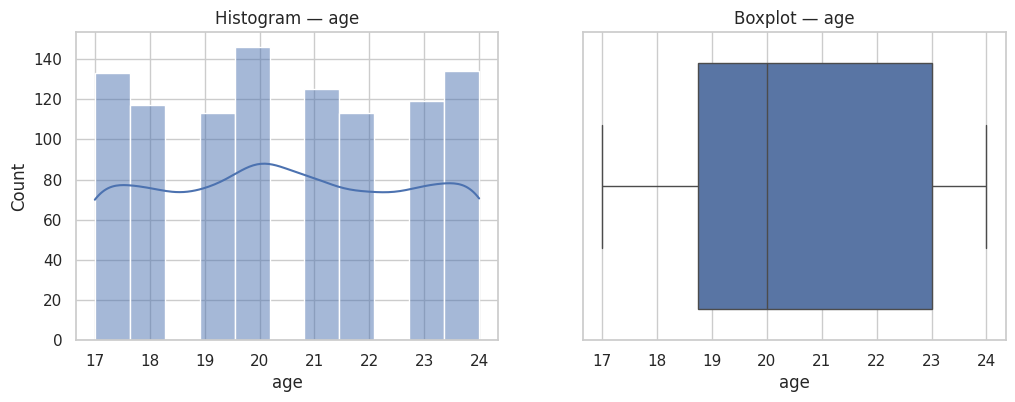

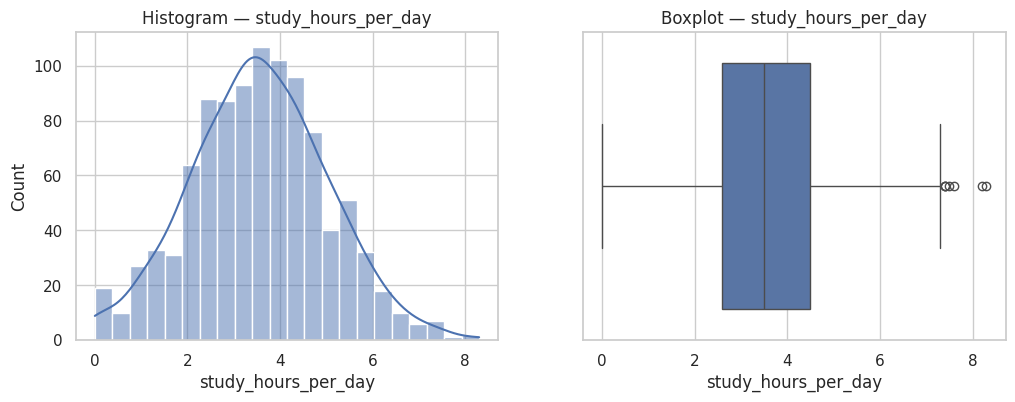

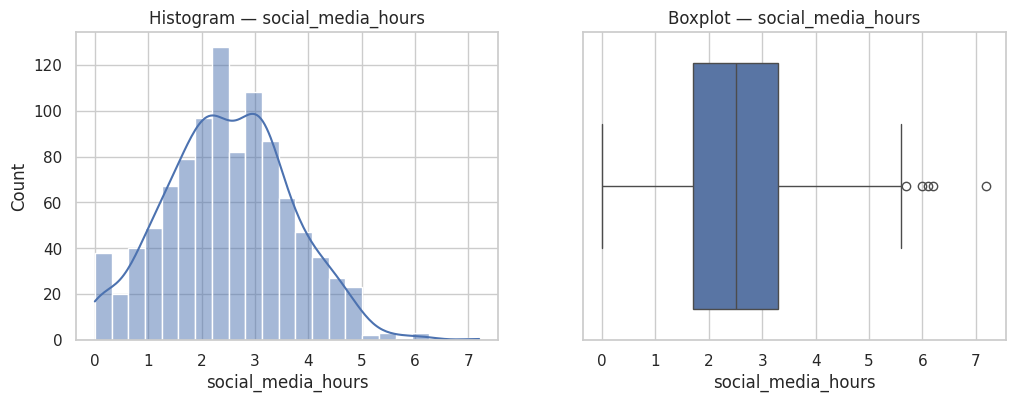

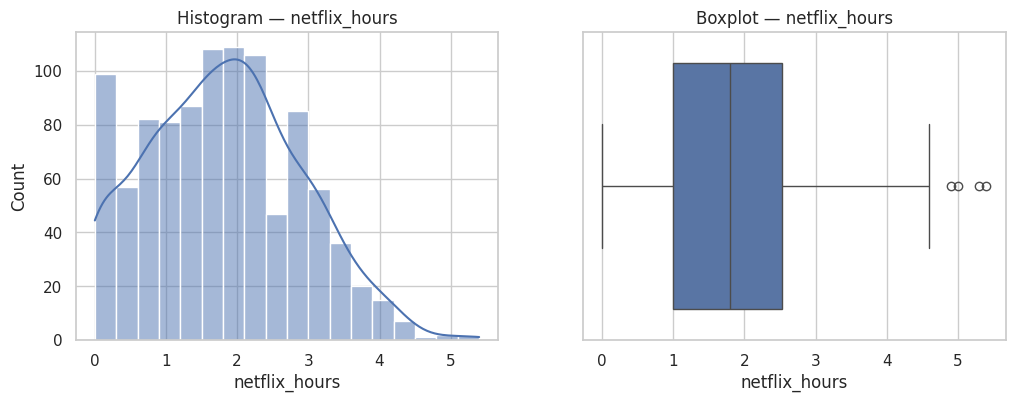

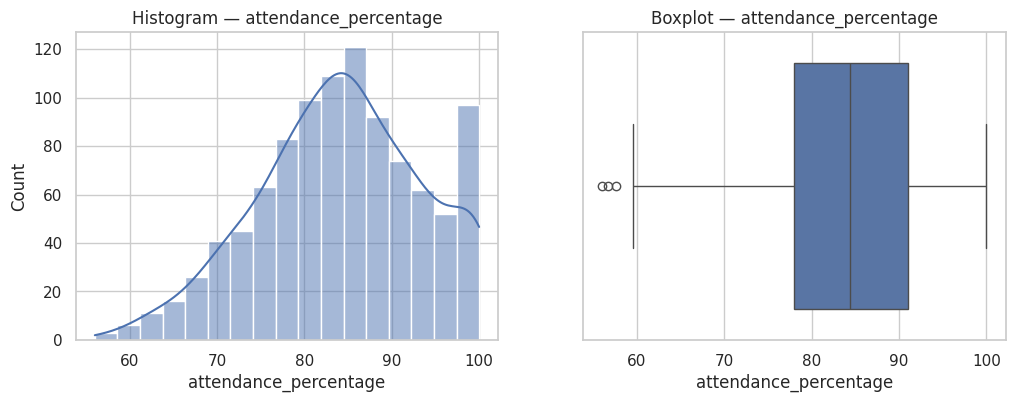

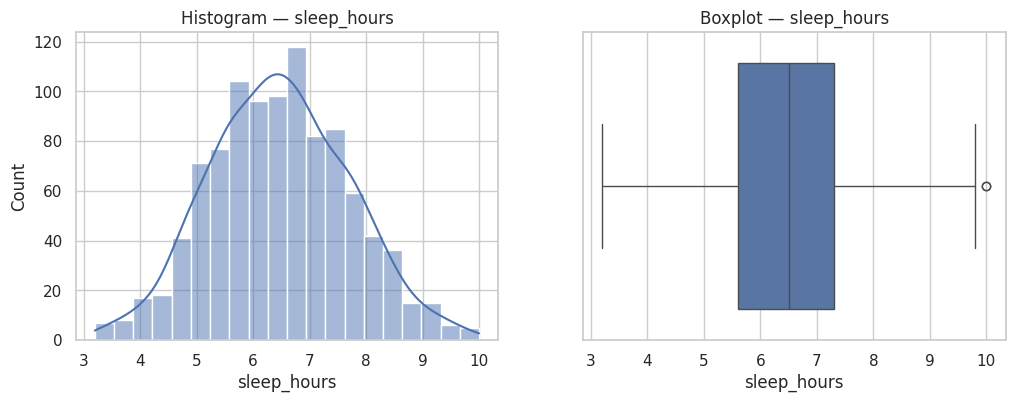

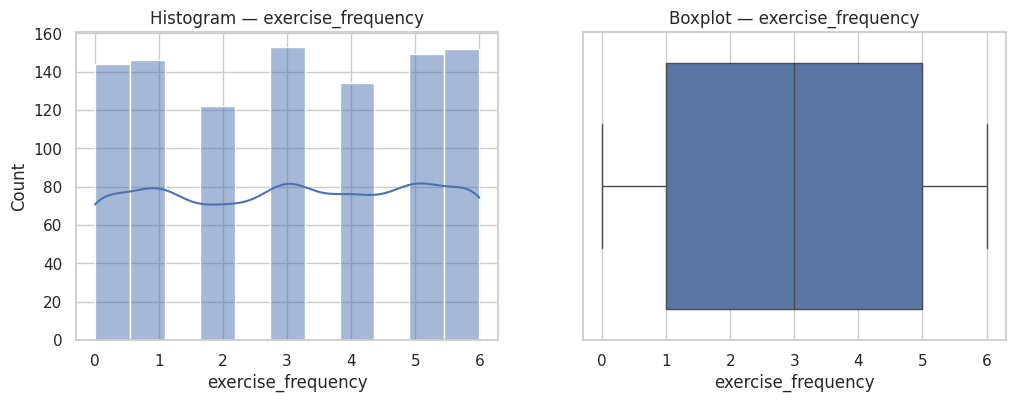

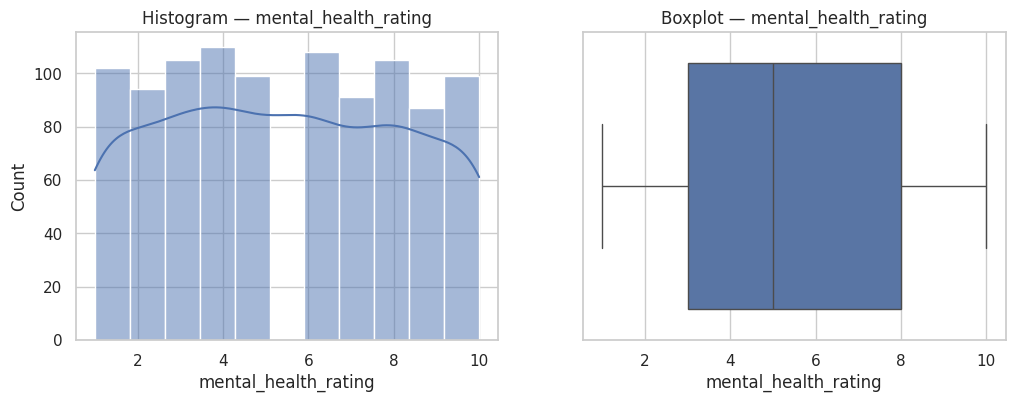

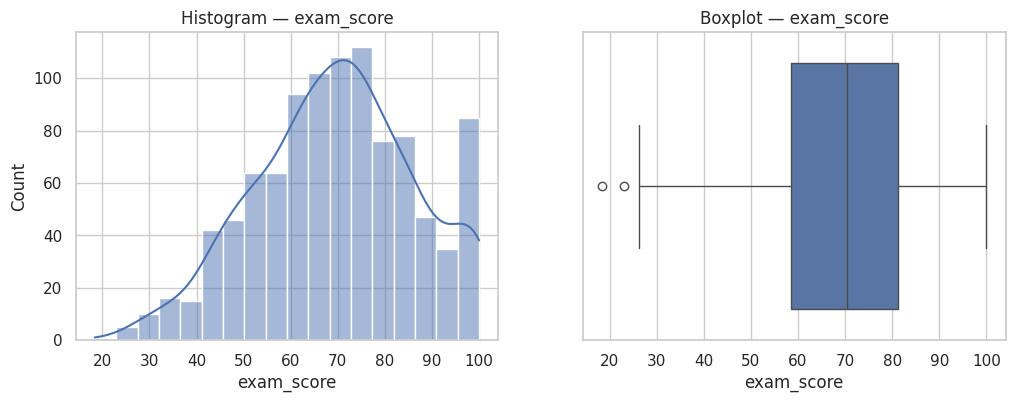

In [14]:
# Histograms + boxplots
for col in numeric_cols:
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    sns.histplot(df[col], kde=True)
    plt.title(f"Histogram — {col}")
    plt.subplot(1,2,2)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot — {col}")
    plt.show()

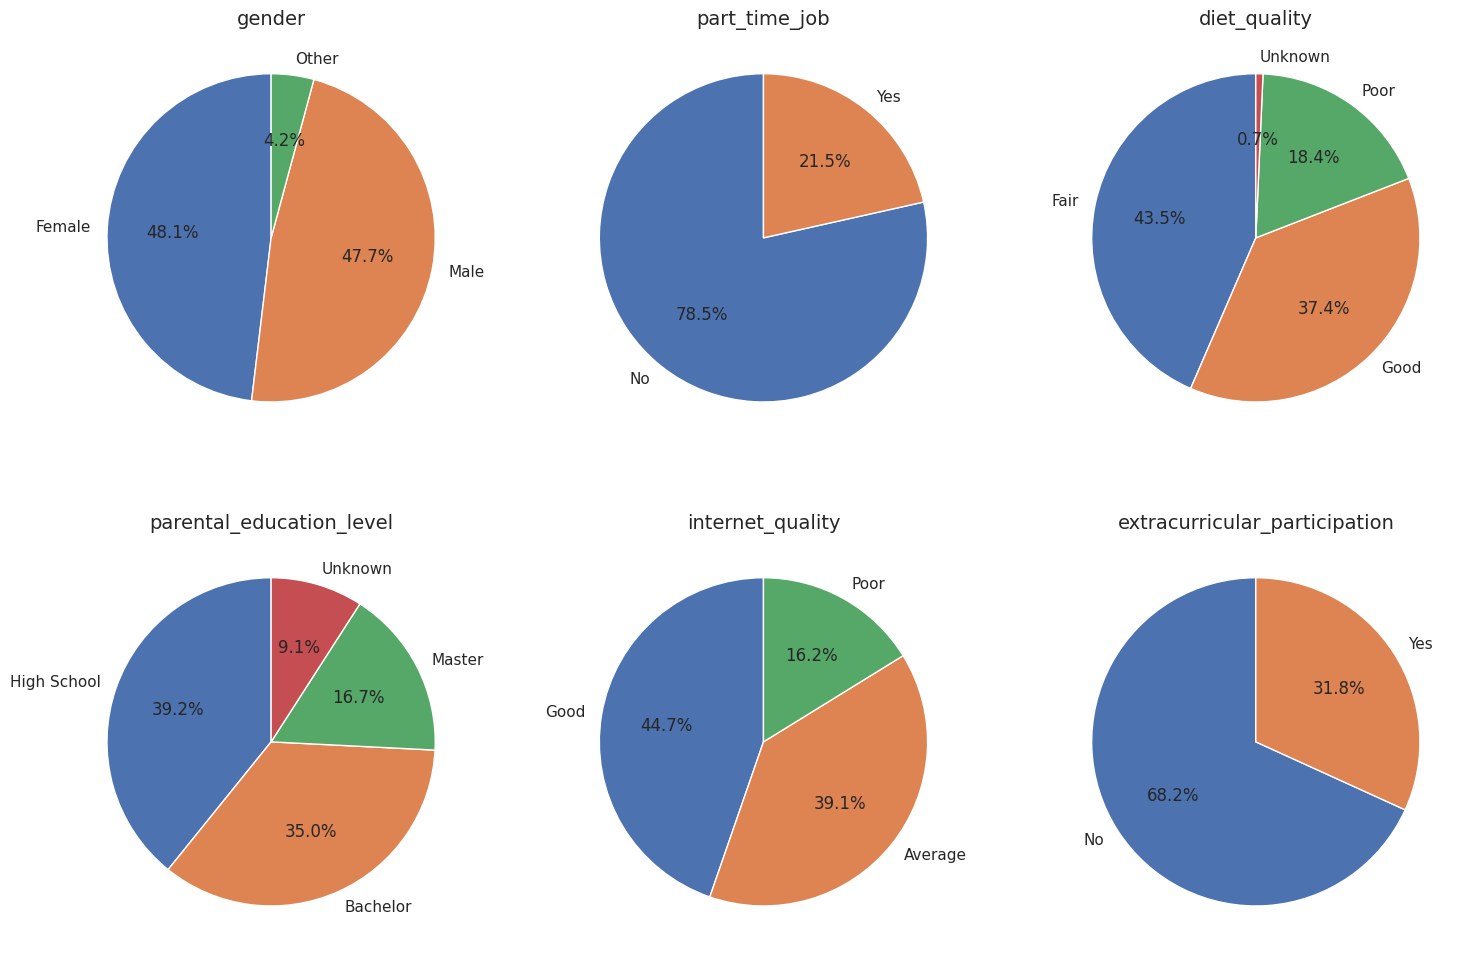

In [ ]:
# Categorical Pie charts
cat_cols_no_id = [col for col in categorical_cols if col != "student_id"]
# Create a 2×3 grid (adjust if you have more or fewer categorical columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()  # flatten 2D axes into a list
for i, col in enumerate(cat_cols_no_id):
    counts = df[col].value_counts()
    labels = counts.index
    sizes = counts.values
    axes[i].pie(
        sizes,
        labels=labels,
        autopct='%1.1f%%',
        startangle=90
    )
    axes[i].set_title(f"{col}", fontsize=14)

# BIVARIATE & MULTIVARIATE ANALYSIS
This stage explored relationships between variables and exam performance. Correlation analysis revealed strong positive associations between exam scores and study-related behaviors, such as study hours and attendance, and negative associations with excessive screen time. Scatterplots and boxplots confirmed these patterns visually, while contingency tables and chi-square tests showed that most categorical variables have weak associations with each other, indicating limited dependency between student characteristics.

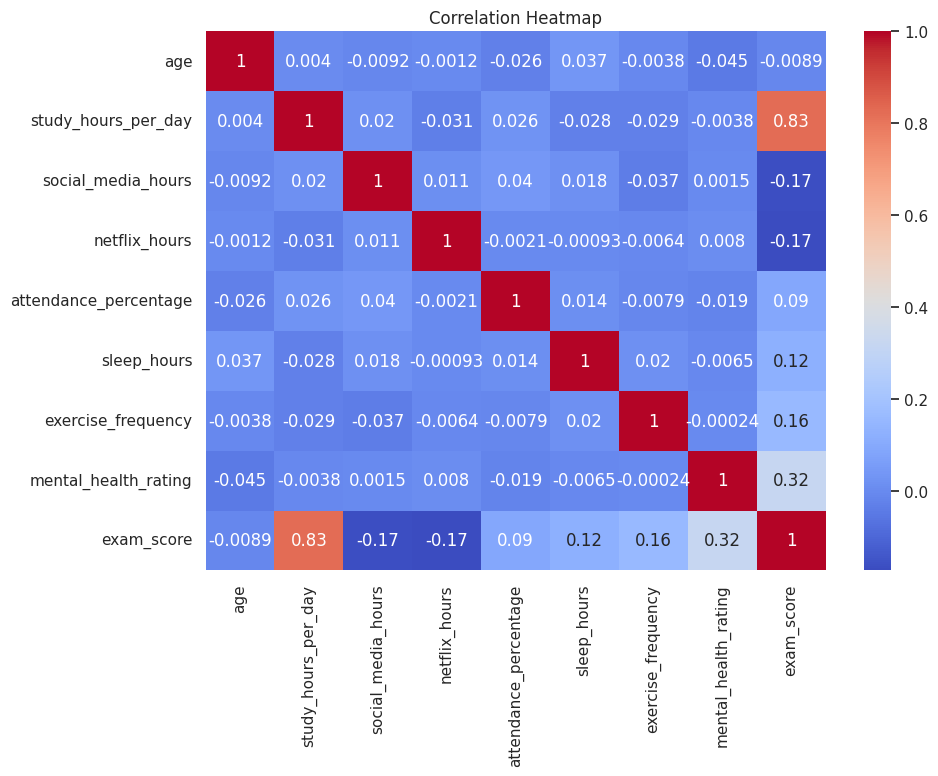

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10,7))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

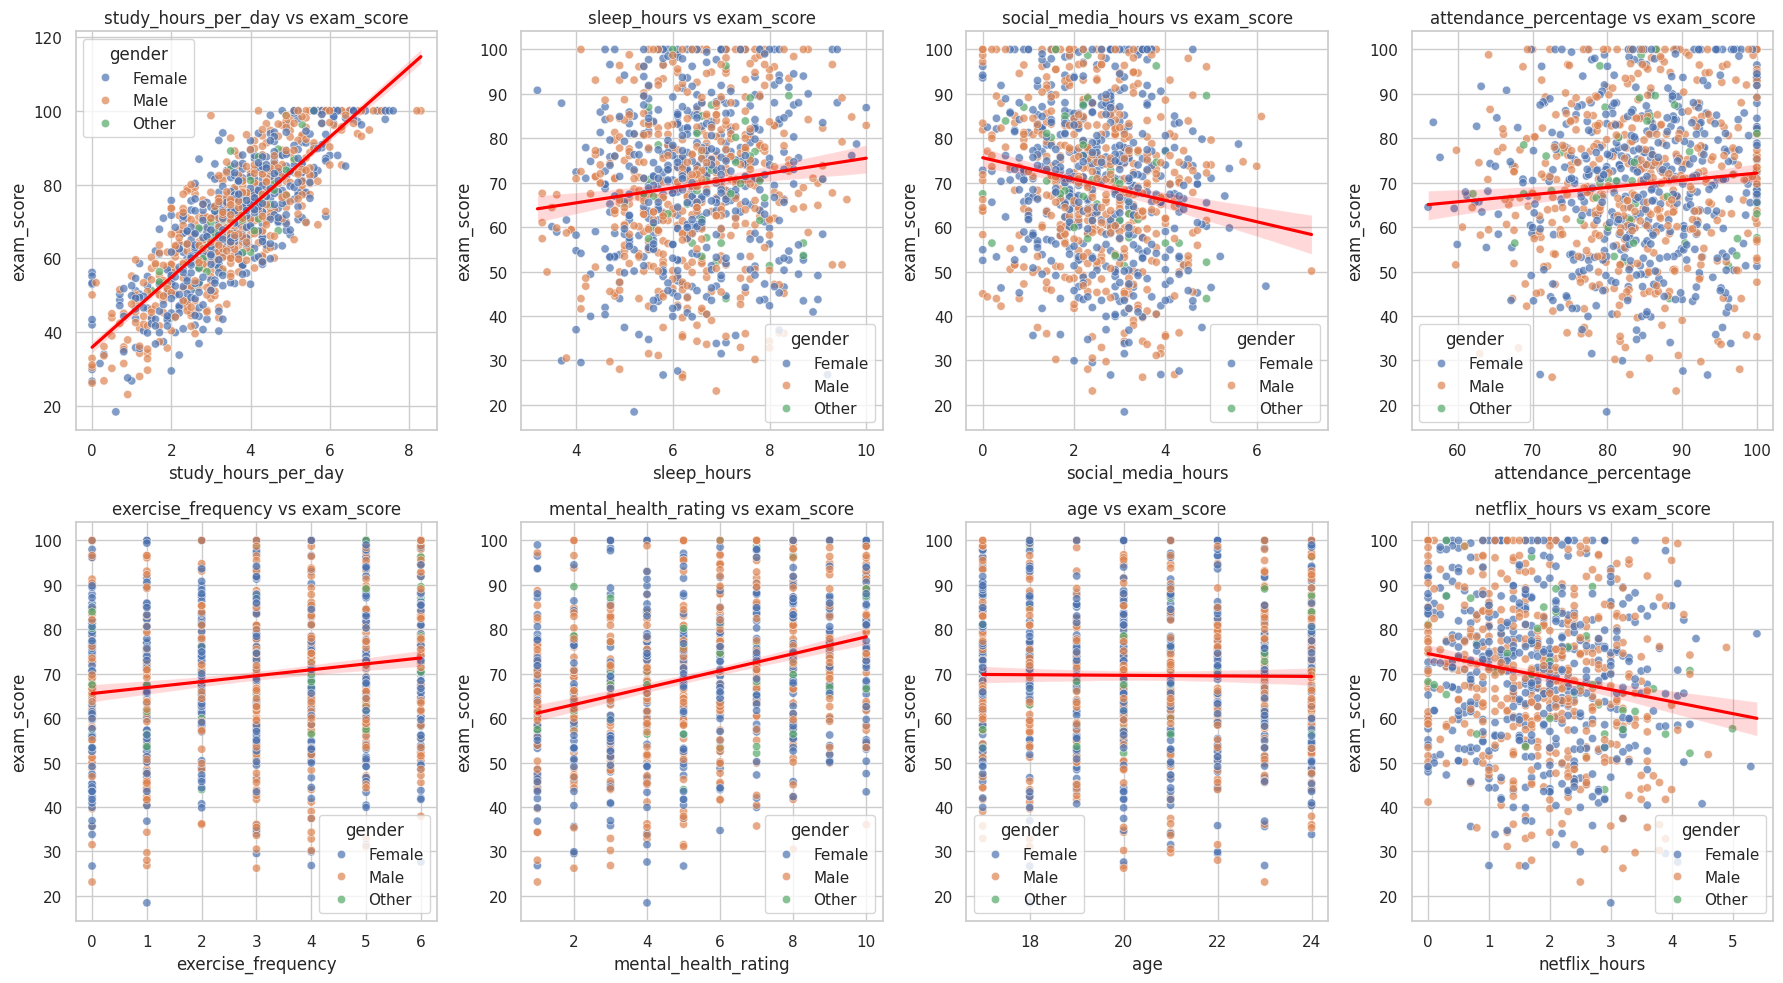

In [ ]:
pairs = [
    ("study_hours_per_day", "exam_score"),
    ("sleep_hours", "exam_score"),
    ("social_media_hours", "exam_score"),
    ("attendance_percentage", "exam_score"),
    ("exercise_frequency", "exam_score"),
    ("mental_health_rating", "exam_score"),
    ("age", "exam_score"),
    ("netflix_hours", "exam_score")
]
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()
for i, (x, y) in enumerate(pairs):
    ax = axes[i]
    # Scatterplot with gender color coding
    sns.scatterplot(data=df, x=x, y=y, hue="gender", alpha=0.7, ax=ax)
    # Add regression line
    sns.regplot(
        data=df,
        x=x,
        y=y,
        scatter=False,
        color="red",
        ax=ax
    )
    ax.set_title(f"{x} vs {y}")
plt.tight_layout()
plt.show()

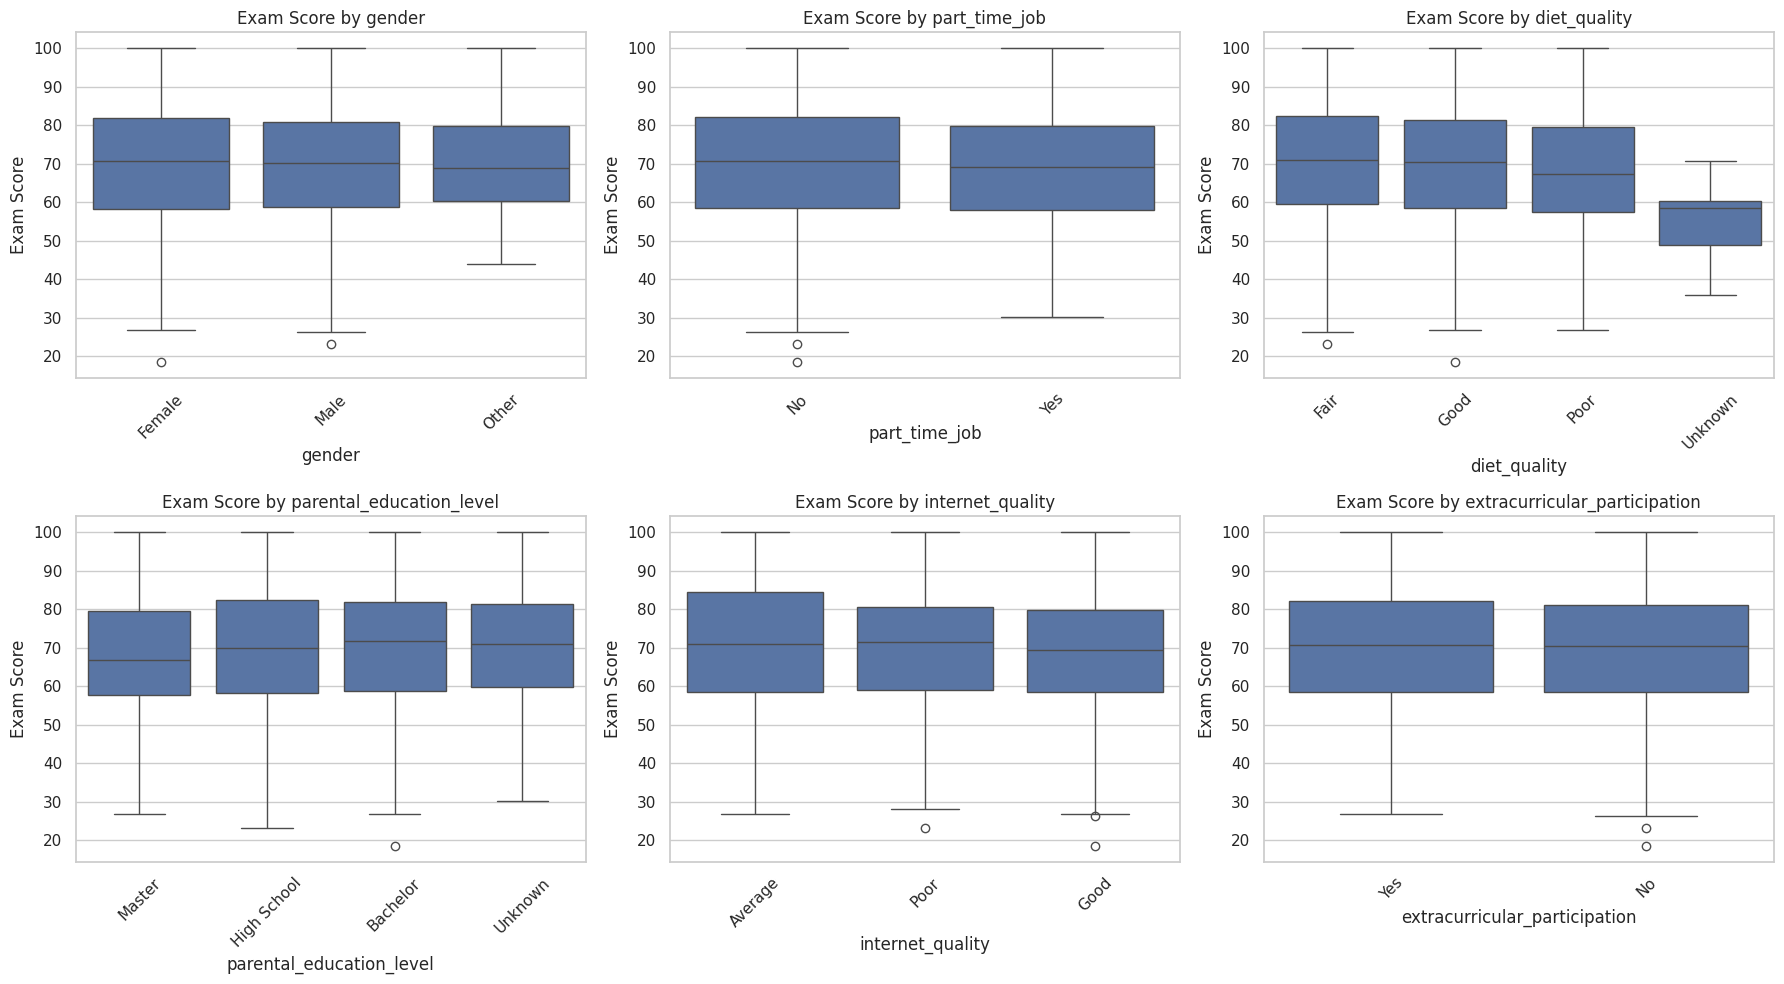

In [ ]:
# Boxplots for all categorical columns
plot_cols = [col for col in categorical_cols if col != "student_id"]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(plot_cols):
    ax = axes[i]
    sns.boxplot(data=df, x=col, y="exam_score", ax=ax)
    ax.set_title(f"Exam Score by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Exam Score")
    # Rotate labels safely (no warnings)
    for label in ax.get_xticklabels():
        label.set_rotation(45)
plt.tight_layout()
plt.show()

In [ ]:
groups = [
    df[df["diet_quality"] == level]["exam_score"]
    for level in df["diet_quality"].dropna().unique()
]
anova_diet = f_oneway(*groups)
print("ANOVA — Diet Quality vs Exam Score")
print("F-statistic:", round(anova_diet.statistic, 3))
print("p-value:", round(anova_diet.pvalue, 4))

ANOVA — Diet Quality vs Exam Score
F-statistic: 2.732
p-value: 0.0427


In [ ]:
groups = [
    df[df["parental_education_level"] == level]["exam_score"]
    for level in df["parental_education_level"].dropna().unique()
]
anova_parent = f_oneway(*groups)
print("ANOVA — Parental Education Level vs Exam Score")
print("F-statistic:", round(anova_parent.statistic, 3))
print("p-value:", round(anova_parent.pvalue, 4))

ANOVA — Parental Education Level vs Exam Score
F-statistic: 0.653
p-value: 0.5814


In [ ]:
groups = [
    df[df["internet_quality"] == level]["exam_score"]
    for level in df["internet_quality"].dropna().unique()
]
anova_internet = f_oneway(*groups)
print("ANOVA — Internet Quality vs Exam Score")
print("F-statistic:", round(anova_internet.statistic, 3))
print("p-value:", round(anova_internet.pvalue, 4))

ANOVA — Internet Quality vs Exam Score
F-statistic: 1.463
p-value: 0.232


In [ ]:
valid_cats = [
    "gender",
    "part_time_job",
    "diet_quality",
    "parental_education_level",
    "internet_quality",
    "extracurricular_participation"
]
for col1, col2 in combinations(valid_cats, 2):
    print(f"\nContingency table: {col1} vs {col2}")
    table = pd.crosstab(df[col1], df[col2])
    display(table)


Contingency table: gender vs part_time_job


part_time_job,No,Yes
gender,,
Female,385,96
Male,368,109
Other,32,10



Contingency table: gender vs diet_quality


diet_quality,Fair,Good,Poor,Unknown
gender,,,,
Female,209,178,91,3
Male,208,182,83,4
Other,18,14,10,0



Contingency table: gender vs parental_education_level


...

internet_quality,Average,Good,Poor
parental_education_level,,,
Bachelor,136,158,56
High School,156,169,67
Master,60,83,24
Unknown,39,37,15



Contingency table: parental_education_level vs extracurricular_participation


extracurricular_participation,No,Yes
parental_education_level,,
Bachelor,236,114
High School,268,124
Master,116,51
Unknown,62,29



Contingency table: internet_quality vs extracurricular_participation


extracurricular_participation,No,Yes
internet_quality,,
Average,267,124
Good,310,137
Poor,105,57


In [ ]:
results = []
valid_cats = [
    "gender",
    "part_time_job",
    "diet_quality",
    "parental_education_level",
    "internet_quality",
    "extracurricular_participation"
]
for col1, col2 in combinations(valid_cats, 2):
    table = pd.crosstab(df[col1], df[col2])
    chi2, p, dof, expected = chi2_contingency(table)
    n = table.sum().sum()
    k = min(table.shape)
    cramer_v = np.sqrt(chi2 / (n * (k - 1)))
    results.append({
        "Variable 1": col1,
        "Variable 2": col2,
        "Chi-square": round(chi2, 3),
        "df": dof,
        "p-value": round(p, 4),
        "Cramér's V": round(cramer_v, 3)
    })
chi_results = pd.DataFrame(results)
display(chi_results)

,Variable 1,Variable 2,Chi-square,df,p-value,Cramér's V
0,gender,part_time_job,1.326,2,0.5153,0.036
1,gender,diet_quality,1.746,6,0.9415,0.030
2,gender,parental_education_level,8.382,6,0.2115,0.065
3,gender,internet_quality,6.517,4,0.1637,0.057
4,gender,extracurricular_participation,0.083,2,0.9591,0.009
5,part_time_job,diet_quality,1.706,3,0.6356,0.041
6,part_time_job,parental_education_level,2.089,3,0.5541,0.046
7,part_time_job,internet_quality,5.123,2,0.0772,0.072
8,part_time_job,extracurricular_participation,0.409,1,0.5224,0.020
9,diet_quality,parental_education_level,7.709,9,0.5638,0.051


# PCA + CLUSTERING
Principal Component Analysis (PCA) was applied to reduce dimensionality and uncover underlying behavioral patterns among students. The first few components captured a substantial portion of the total variance, mainly driven by academic engagement and lifestyle factors. Clustering analysis using KMeans identified broad groupings of students with similar behavior profiles. While different methods suggested different optimal numbers of clusters, the results consistently indicate meaningful segmentation between higher-engagement and lower-engagement student groups.

In [ ]:
# Remove ID column
if "student_id" in df.columns:
    df_model = df.drop(columns=["student_id"])
else:
    df_model = df.copy()
num_features = df_model.select_dtypes(include=np.number).columns.tolist()
cat_features = df_model.select_dtypes(exclude=np.number).columns.tolist()
# Preprocessing pipeline
ct = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(drop="first"), cat_features)
])
X = ct.fit_transform(df_model)

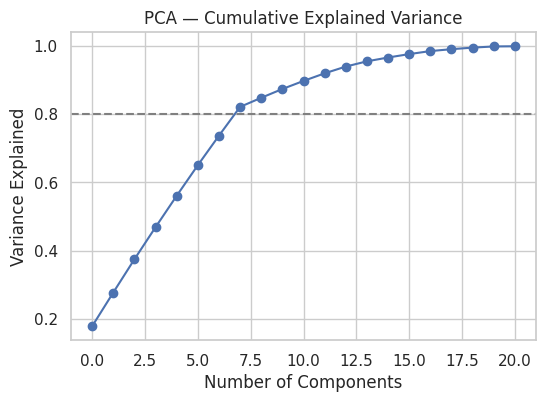


Components needed to explain ≥80% variance: 8


In [ ]:
# -------------------
# PCA
# -------------------
pca = PCA()
X_pca = pca.fit_transform(X)
plt.figure(figsize=(6,4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.axhline(0.80, linestyle='--', color='gray')
plt.title("PCA — Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Variance Explained")
plt.show()
# Identify components needed for 80%
components_needed = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.80) + 1
print(f"\nComponents needed to explain ≥80% variance: {components_needed}")

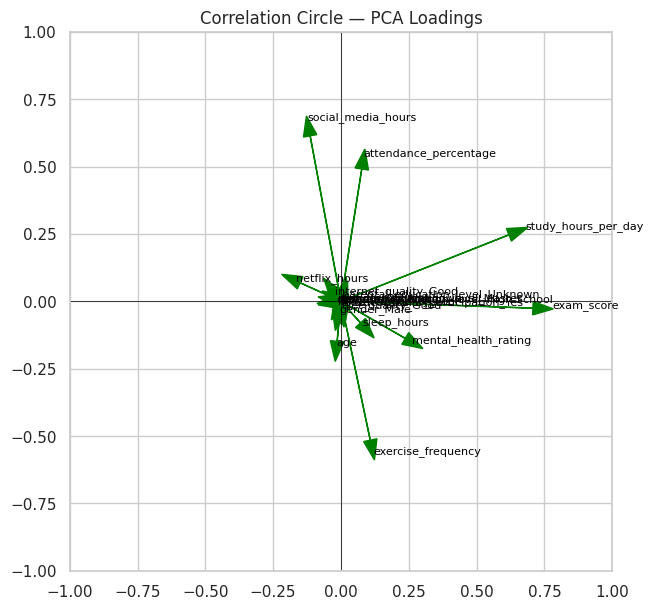

In [ ]:
# Correlation circle (PC1 & PC2)
loadings = pca.components_.T[:, :2]
# Feature names after encoding
ohe = ct.named_transformers_["cat"]
ohe_names = ohe.get_feature_names_out(cat_features)
feature_names = list(num_features) + list(ohe_names)
plt.figure(figsize=(7,7))
for i, (x, y) in enumerate(loadings):
    plt.arrow(0, 0, x, y, head_width=0.05, color="green")
    plt.text(x*1.1, y*1.1, feature_names[i], fontsize=8, color="black")
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlim(-1,1)
plt.ylim(-1,1)
plt.title("Correlation Circle — PCA Loadings")
plt.show()

In [ ]:
# We made another plot as we see the first one is so noisy because we plot all the variables but now we select only the most strenght ones according to the formula defined below.
loading_strength = np.sqrt(loadings[:, 0]**2 + loadings[:, 1]**2)
threshold = 0.25
mask = loading_strength >= threshold

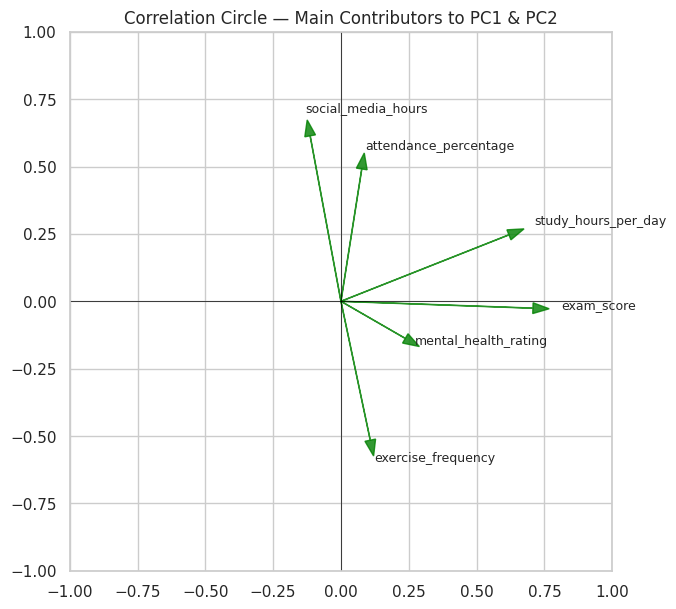

In [ ]:
plt.figure(figsize=(7,7))
for i, (x, y) in enumerate(loadings[mask]):
    plt.arrow(0, 0, x, y, head_width=0.04, color="green", alpha=0.8)
    plt.text(x*1.15, y*1.15, np.array(feature_names)[mask][i],
             fontsize=9)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlim(-1,1)
plt.ylim(-1,1)
plt.title("Correlation Circle — Main Contributors to PC1 & PC2")
plt.grid(True)
plt.show()

In [ ]:
loading_df = pd.DataFrame({
    "Feature": feature_names,
    "PC1 Loading": loadings[:, 0],
    "PC2 Loading": loadings[:, 1]
})
loading_df_sorted = loading_df.sort_values(by="PC1 Loading", ascending=False)
loading_df_sorted

,Feature,PC1 Loading,PC2 Loading
8,exam_score,0.707730,-0.025504
1,study_hours_per_day,0.619260,0.246637
7,mental_health_rating,0.237220,-0.137690
6,exercise_frequency,0.108094,-0.515274
4,attendance_percentage,0.076732,0.491046
5,sleep_hours,0.072241,-0.080117
17,parental_education_level_Unknown,0.003496,0.016116
12,diet_quality_Good,0.002531,-0.021141
19,internet_quality_Poor,0.001336,-0.006739
10,gender_Other,0.001007,0.003032


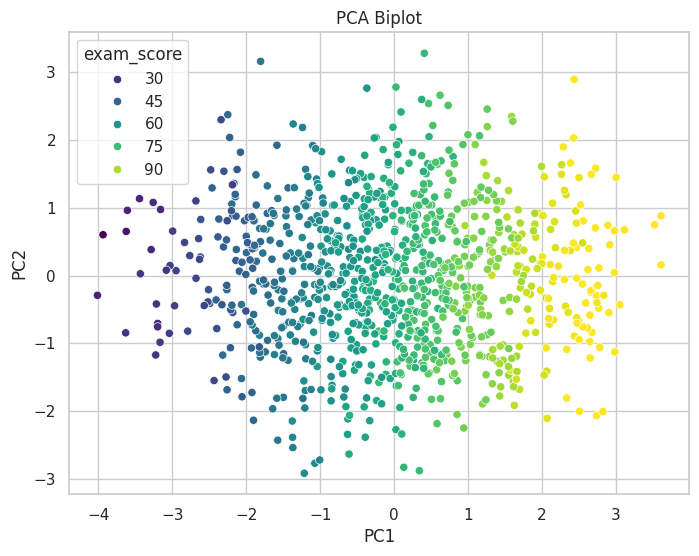

In [ ]:
# -------------------
# Biplot
# -------------------
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df["exam_score"], palette="viridis")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Biplot")
plt.show()

In [ ]:
# Clustering — KMeans
inertia = []
sil_scores = []
K_range = range(2,10)
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10)
    labels = km.fit_predict(X)
    inertia.append(km.inertia_)
    if len(df) > k:
        sil_scores.append(silhouette_score(X, labels))
    else:
        sil_scores.append(np.nan)

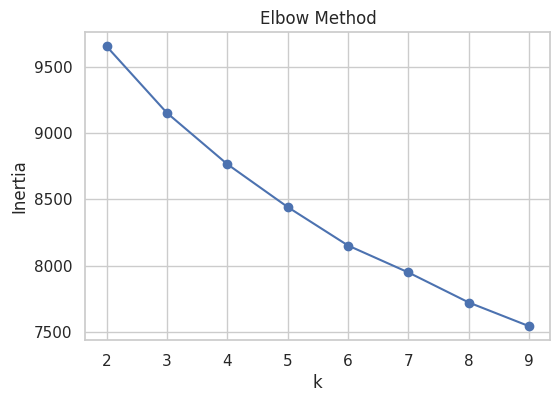

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()

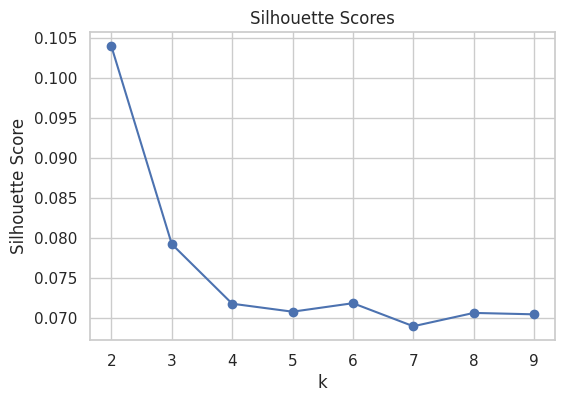


Best number of clusters according to silhouette score: 2


In [ ]:
plt.figure(figsize=(6,4))
plt.plot(K_range, sil_scores, marker='o')
plt.title("Silhouette Scores")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.show()
# Best k
best_k = K_range[np.nanargmax(sil_scores)]
print("\nBest number of clusters according to silhouette score:", best_k)

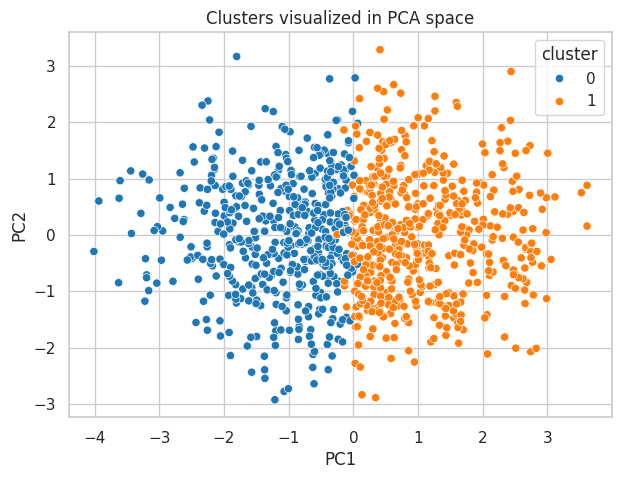

In [ ]:
# Fit final model
kmeans = KMeans(n_clusters=best_k, n_init=10)
cluster_labels = kmeans.fit_predict(X)
# Add clusters to df
df["cluster"] = cluster_labels
plt.figure(figsize=(7,5))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df["cluster"], palette="tab10")
plt.title("Clusters visualized in PCA space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [ ]:
groups = [
    df[df["cluster"] == c]["exam_score"]
    for c in sorted(df["cluster"].unique())
]
anova_cluster = f_oneway(*groups)
print("ANOVA — Cluster vs Exam Score")
print("F-statistic:", round(anova_cluster.statistic, 3))
print("p-value:", round(anova_cluster.pvalue, 6))

ANOVA — Cluster vs Exam Score
F-statistic: 1723.242
p-value: 0.0


In [ ]:
print("\nCluster sizes:")
display(df["cluster"].value_counts())
print("\nCluster means:")
display(df.groupby("cluster")[num_features].mean())


Cluster sizes:


,count
cluster,
1,518
0,482



Cluster means:


,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
cluster,,,,,,,,,
0,20.500000,2.557261,2.676763,1.989419,83.281950,6.298755,2.885892,4.423237,55.676141
1,20.496139,4.473938,2.346139,1.661776,84.922394,6.629537,3.187259,6.382239,82.559073


# Summary

The dataset describes university students habits, lifestyle, and environmental factors and how they relate to academic performance. It includes behavioral variables (study hours, sleep, social media use), wellbeing indicators (diet, exercise, mental health), and background features (parental education, gender, job status). Overall, the data reveals substantial variation in students' daily habits and exam outcomes, allowing meaningful exploration of performance patterns.

**Patterns from Univariate Analysis**


*   Study hours, sleep duration, and exam scores show wide variability among
students.
*   Social media and Netflix usage follow right-skewed distributions (many low-usage students and few high-usage ones).
*   Most students have “Good” or “Fair” diet quality and "Average" internet quality.
*   Mental health ratings tend to be moderate to high.
*   Categorical variables such as part-time job and extracurricular participation are imbalanced.

**Patterns from Bivariate & Multivariate Analysis**


*   Study hours and exam score show a positive relationship—students who study more tend to score higher.
*   Social media hours show a weak negative relationship with exam scores.
*   Sleep hours show a moderate positive association with performance.
*   Gender does not strongly differentiate exam results, based on boxplots.
*   The correlation matrix confirms that study habits influence exam outcomes more than lifestyle factors.

**Patterns from PCA**

*   PC1 is strongly driven by exam score and study hours, meaning it represents “academic engagement.”
*   PC2 is driven by lifestyle variables, especially social media use and exercise frequency.
*   PCA separates students mostly by their balance between academic effort and lifestyle habits, creating meaningful structure in the data.
*   Only a few components are needed to explain most of the variance, meaning many variables are correlated.

**Patterns from Clustering**

*   The optimal cluster number (from silhouette score) groups students into distinct profiles.
*   One cluster typically represents high-performing, high-study students.
*   Another cluster contains low-study, high-social-media students.
*   A third cluster often captures average students with moderate habits.
*   Clusters visualize well in PCA space, meaning the natural groupings in the data are strong.

**Overall Insight**

The dataset shows that academic performance is most strongly influenced by study behavior, with lifestyle factors playing a secondary but still noticeable role. PCA and clustering confirm the presence of clear behavioral student profiles.